In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")

%matplotlib inline

In [2]:
fund_master = pd.read_csv(
    "../data/raw/01_fund_master.csv"
)

aum = pd.read_csv(
    "../data/raw/03_aum_by_fund_house.csv"
)

sip = pd.read_csv(
    "../data/raw/04_monthly_sip_inflows.csv"
)

category = pd.read_csv(
    "../data/raw/05_category_inflows.csv"
)

folio = pd.read_csv(
    "../data/raw/06_industry_folio_count.csv"
)

transactions = pd.read_csv(
    "../data/raw/08_investor_transactions.csv"
)

performance = pd.read_csv(
    "../data/raw/07_scheme_performance.csv"
)

In [3]:
datasets = {
    "fund_master": fund_master,
    "aum": aum,
    "sip": sip,
    "category": category,
    "folio": folio,
    "transactions": transactions,
    "performance": performance
}

for name, df in datasets.items():

    print("\n" + "="*60)

    print(name)

    print("Shape:", df.shape)


fund_master
Shape: (40, 15)

aum
Shape: (90, 5)

sip
Shape: (48, 6)

category
Shape: (144, 3)

folio
Shape: (21, 6)

transactions
Shape: (32778, 13)

performance
Shape: (40, 19)


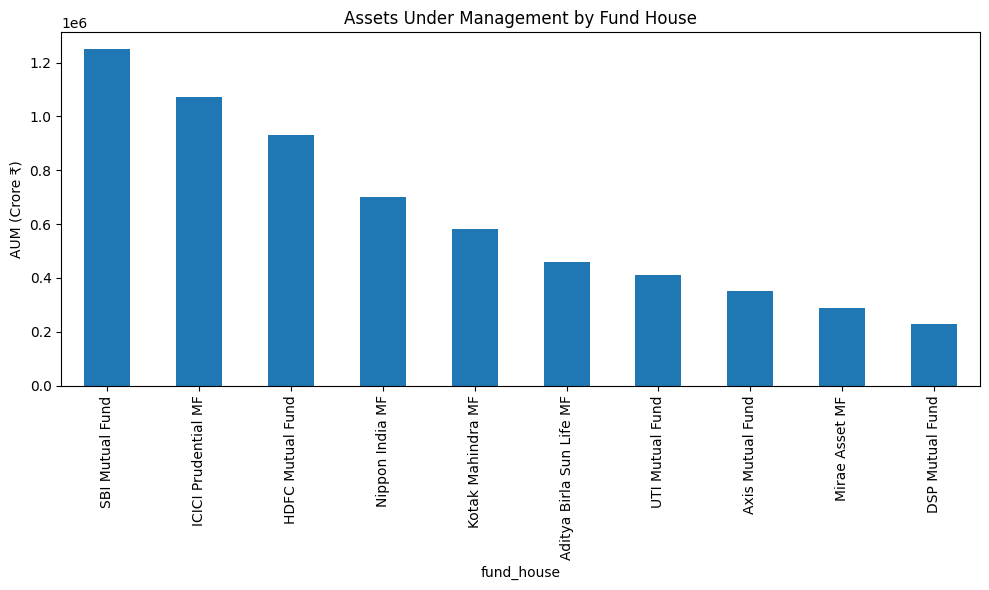

In [4]:
aum_latest = (
    aum
    .groupby("fund_house")["aum_crore"]
    .max()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

aum_latest.plot(kind="bar")

plt.title(
    "Assets Under Management by Fund House"
)

plt.ylabel("AUM (Crore ₹)")

plt.tight_layout()

plt.show()

In [5]:
sip.columns

Index(['month', 'sip_inflow_crore', 'active_sip_accounts_crore',
       'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct'],
      dtype='str')

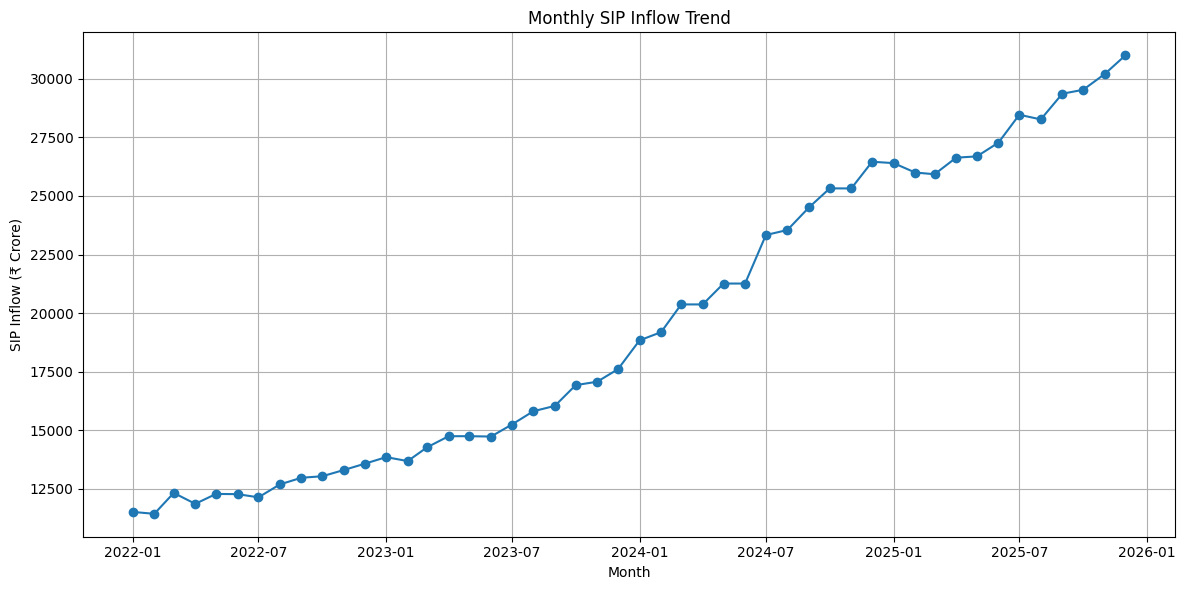

In [8]:
sip['month'] = pd.to_datetime(sip['month'])

plt.figure(figsize=(12,6))

plt.plot(
    sip['month'],
    sip['sip_inflow_crore'],
    marker='o'
)

plt.title("Monthly SIP Inflow Trend")

plt.xlabel("Month")

plt.ylabel("SIP Inflow (₹ Crore)")

plt.grid(True)

plt.tight_layout()

plt.show()

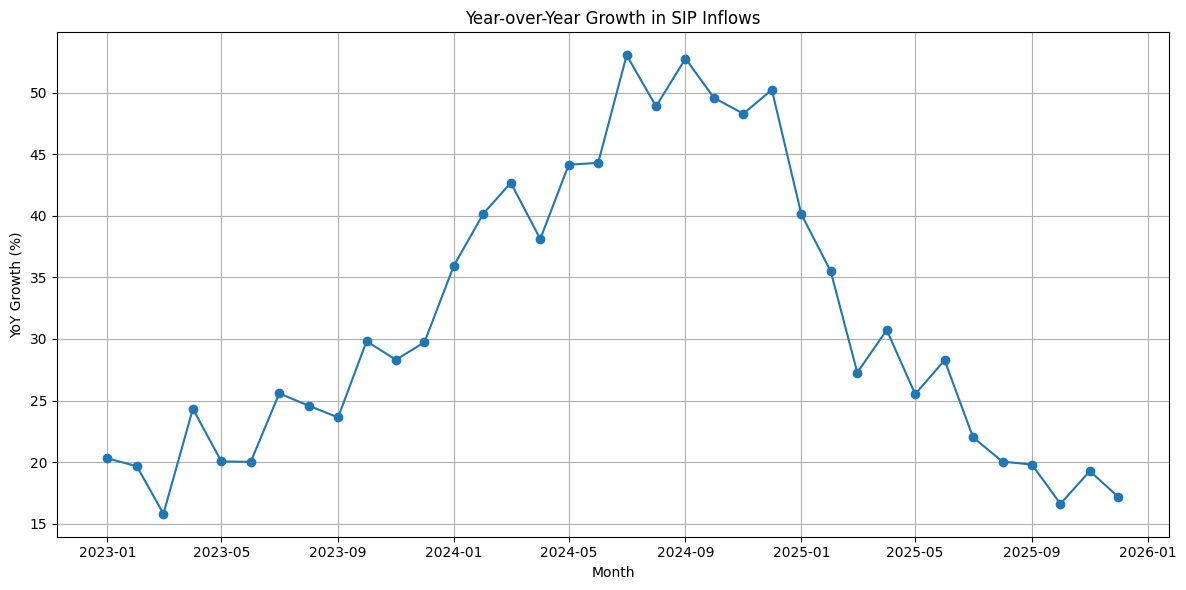

In [9]:
plt.figure(figsize=(12,6))

plt.plot(
    sip['month'],
    sip['yoy_growth_pct'],
    marker='o'
)

plt.title("Year-over-Year Growth in SIP Inflows")

plt.xlabel("Month")

plt.ylabel("YoY Growth (%)")

plt.grid(True)

plt.tight_layout()

plt.show()

In [10]:
category.head()

,month,category,net_inflow_crore
0,2024-04,Large Cap,2413.0
1,2024-04,Mid Cap,3897.0
2,2024-04,Small Cap,3533.0
3,2024-04,Flexi Cap,4947.0
4,2024-04,Large & Mid Cap,4214.0


In [11]:
category.columns.tolist()

['month', 'category', 'net_inflow_crore']

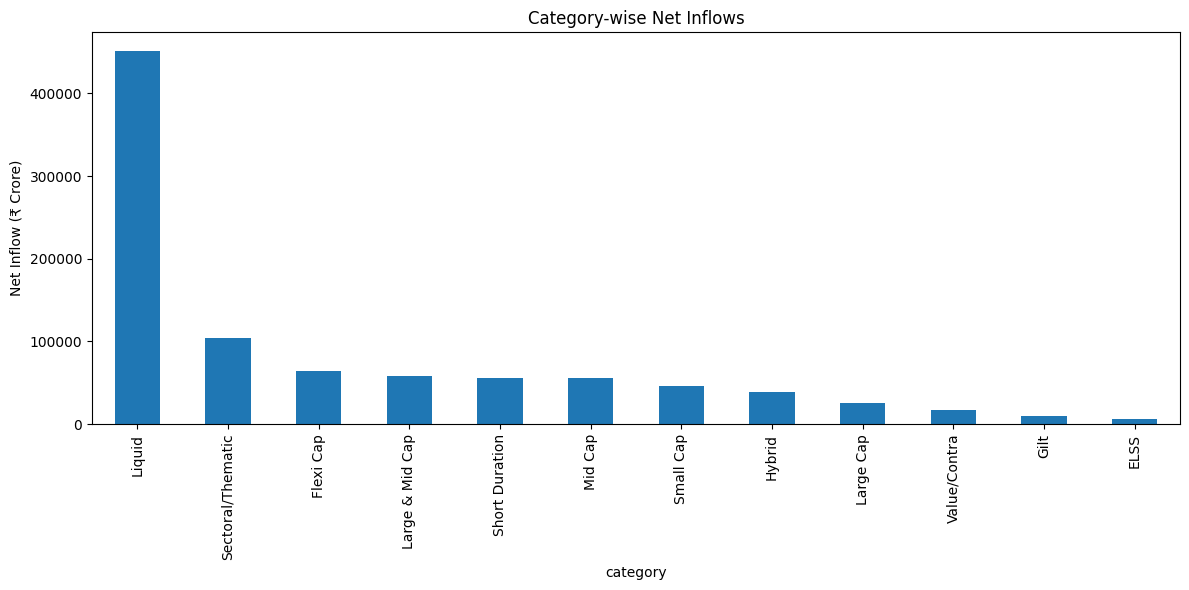

In [12]:
category_totals = (
    category
    .groupby('category')['net_inflow_crore']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

category_totals.plot(kind='bar')

plt.title("Category-wise Net Inflows")

plt.ylabel("Net Inflow (₹ Crore)")

plt.tight_layout()

plt.show()

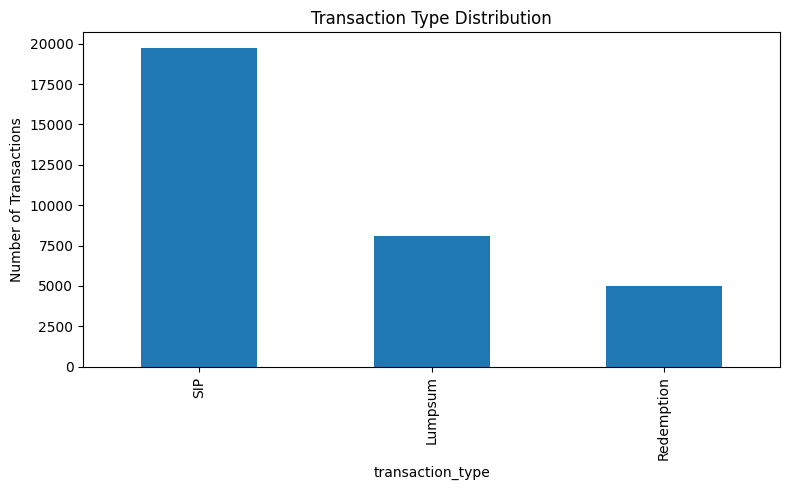

In [13]:
transactions['transaction_type'].value_counts().plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Transaction Type Distribution")

plt.ylabel("Number of Transactions")

plt.tight_layout()

plt.show()

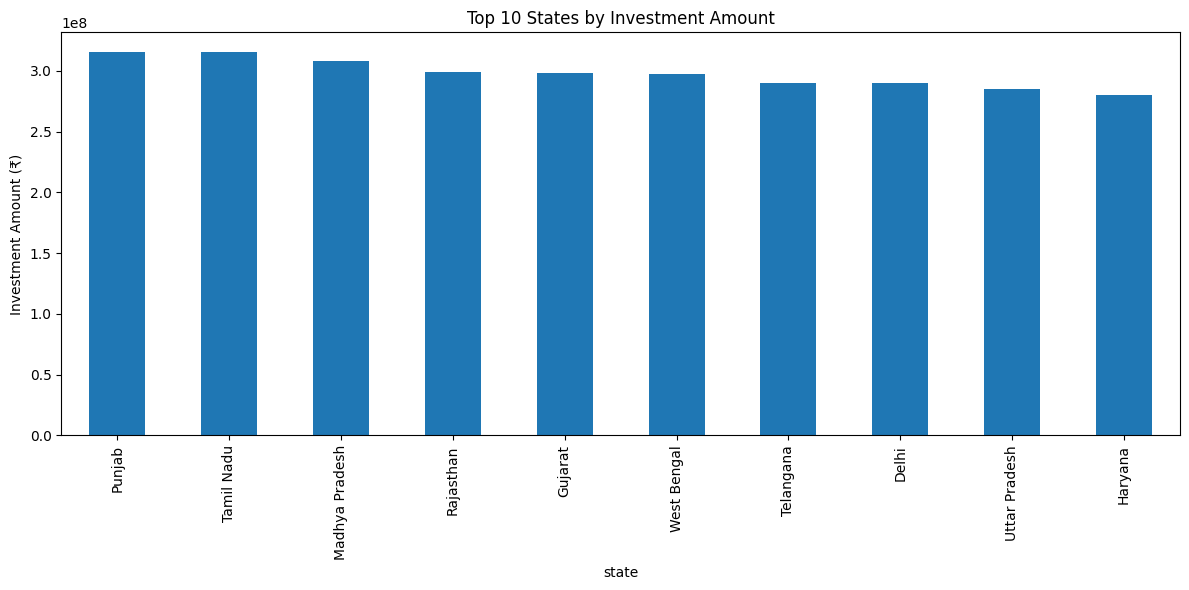

In [14]:
state_investment = (
    transactions
    .groupby('state')['amount_inr']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

state_investment.plot(kind='bar')

plt.title("Top 10 States by Investment Amount")

plt.ylabel("Investment Amount (₹)")

plt.tight_layout()

plt.show()

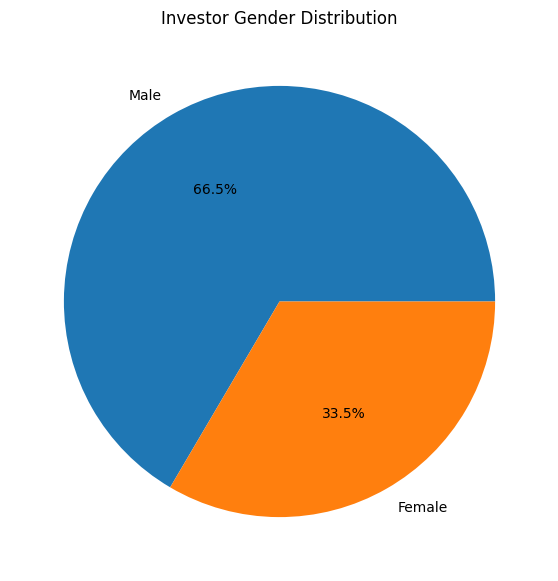

In [15]:
transactions['gender'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(7,7)
)

plt.title("Investor Gender Distribution")

plt.ylabel("")

plt.show()

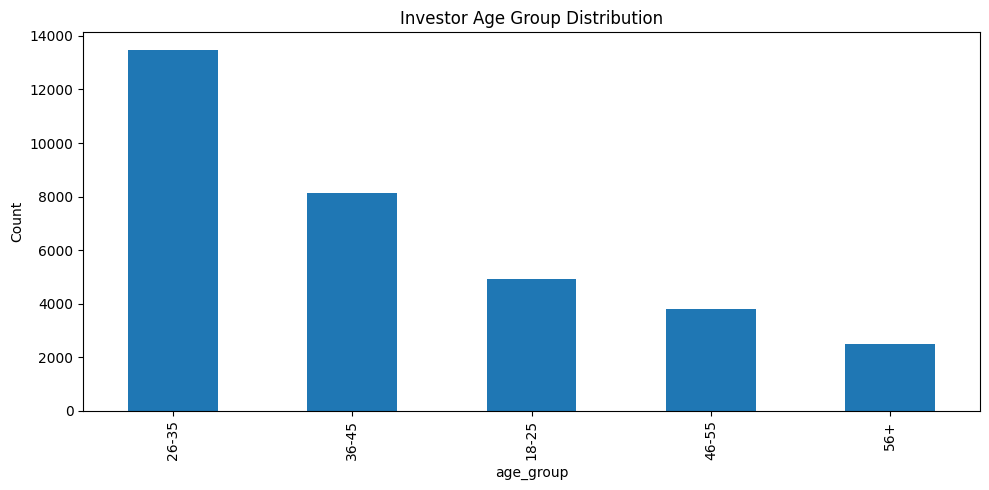

In [16]:
transactions['age_group'].value_counts().plot(
    kind='bar',
    figsize=(10,5)
)

plt.title("Investor Age Group Distribution")

plt.ylabel("Count")

plt.tight_layout()

plt.show()

In [17]:
transactions['city_tier'].value_counts()

city_tier
T30    21719
B30    11059
Name: count, dtype: int64

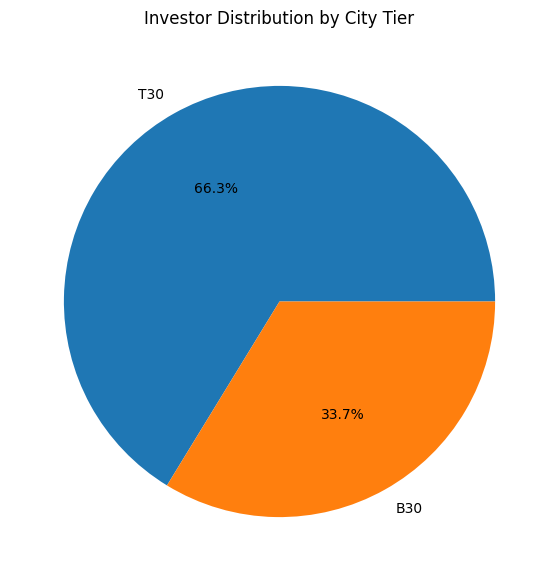

In [18]:
transactions['city_tier'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(7,7)
)

plt.title("Investor Distribution by City Tier")

plt.ylabel("")

plt.show()

In [21]:
transactions['annual_income_lakh'].describe()

count    32778.000000
mean        26.181219
std         20.805425
min          3.000000
25%         10.600000
50%         19.700000
75%         37.400000
max         99.700000
Name: annual_income_lakh, dtype: float64

In [22]:
performance['risk_grade'].value_counts()

risk_grade
Moderate           16
High                8
Very High           6
Low                 6
Moderately High     4
Name: count, dtype: int64

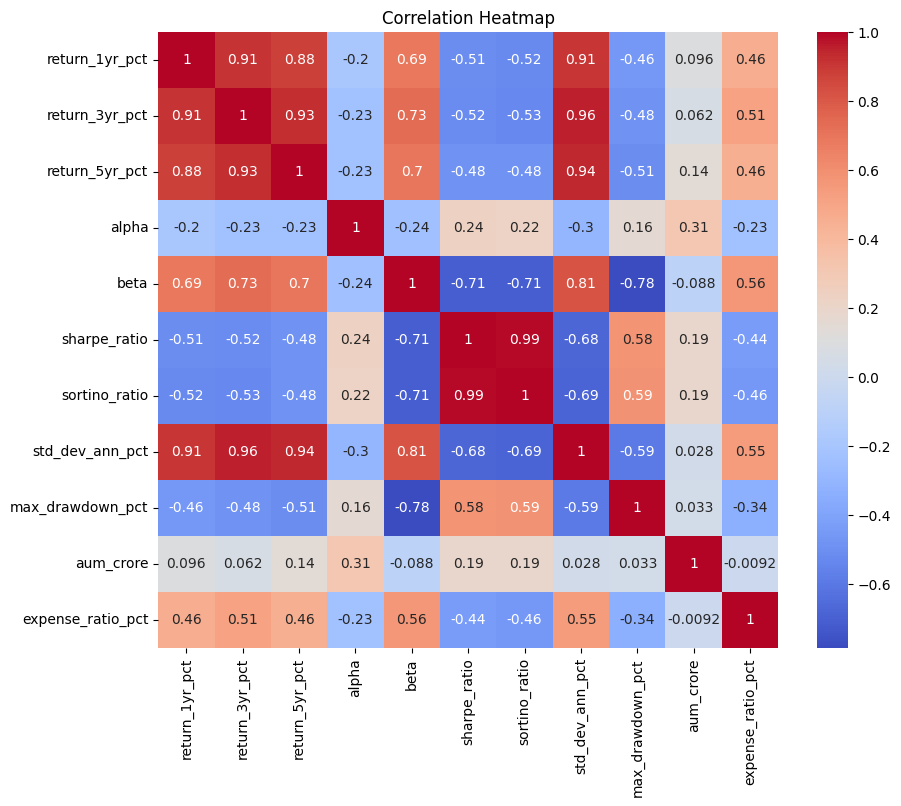

In [23]:
numeric_cols = [
    'return_1yr_pct',
    'return_3yr_pct',
    'return_5yr_pct',
    'alpha',
    'beta',
    'sharpe_ratio',
    'sortino_ratio',
    'std_dev_ann_pct',
    'max_drawdown_pct',
    'aum_crore',
    'expense_ratio_pct'
]

plt.figure(figsize=(10,8))

sns.heatmap(
    performance[numeric_cols].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

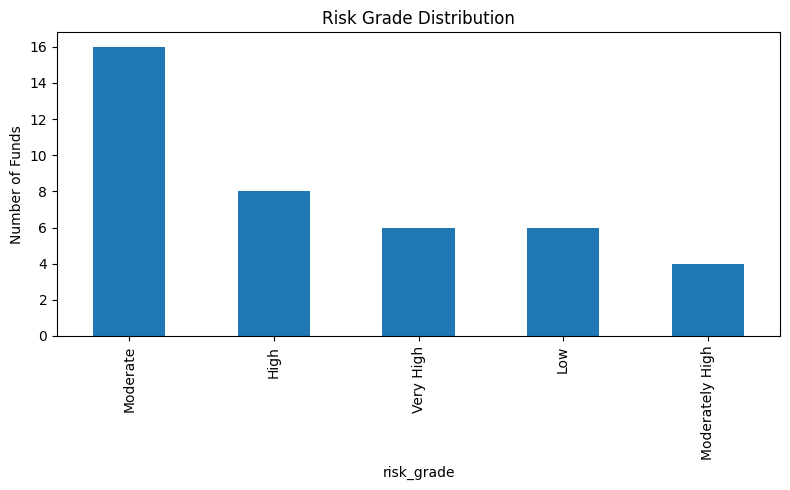

In [24]:
performance['risk_grade'].value_counts().plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Risk Grade Distribution")

plt.ylabel("Number of Funds")

plt.tight_layout()

plt.show()

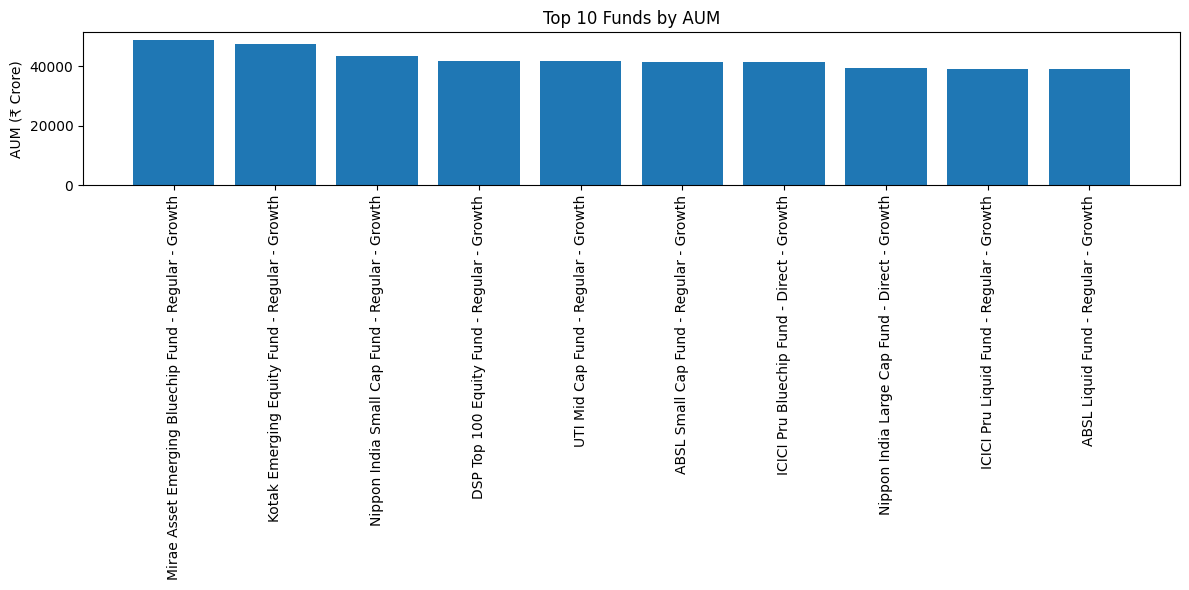

In [25]:
top_funds = (
    performance
    .sort_values(
        by='aum_crore',
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(12,6))

plt.bar(
    top_funds['scheme_name'],
    top_funds['aum_crore']
)

plt.xticks(rotation=90)

plt.title("Top 10 Funds by AUM")

plt.ylabel("AUM (₹ Crore)")

plt.tight_layout()

plt.show()

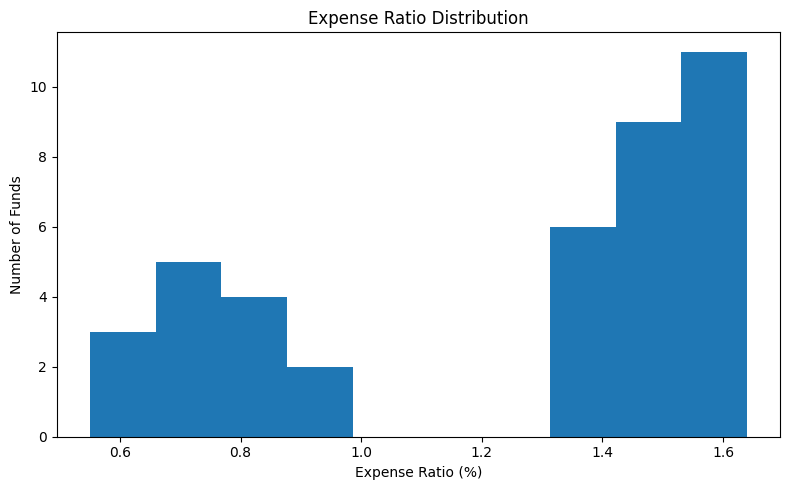

In [26]:
plt.figure(figsize=(8,5))

plt.hist(
    performance['expense_ratio_pct'],
    bins=10
)

plt.title("Expense Ratio Distribution")

plt.xlabel("Expense Ratio (%)")

plt.ylabel("Number of Funds")

plt.tight_layout()

plt.show()